# Training Baseline — Predicción de Mora Genuina

Entrena y compara baselines de clasificación binaria sobre `target_mora_genuina`.

**Dataset:** `training/data/dataset_morosidad_limpio.csv` (461k filas, 2020-2025)  
**Split principal:** temporal (2020-2023 → 2024-2025)  
**Modelos:** Logistic Regression · Random Forest · XGBoost · LightGBM  
**Métricas:** AUC-ROC · F1 · Precision · Recall · Balanced Accuracy

### Experimentos adicionales
| # | Experimento | Objetivo |
|---|-------------|----------|
| 1 | Sin predictores dominantes | Detectar modelo perezoso |
| 2 | Feature macro (IPC Argentina) | Contexto económico externo |
| 3 | Error por carrera | Segmentación por facultad |
| 4 | Umbral de decisión | Optimizar costo de negocio |
| 5 | Rendimiento académico (alumno_asignatura) | Materias críticas como proxy de abandono |

In [1]:
## Instalación de dependencias — ejecutar siempre al iniciar un kernel nuevo
import sys, subprocess

packages = [
    'scikit-learn>=1.4',
    'xgboost>=2.0',
    'lightgbm>=4.0',
    'imbalanced-learn>=0.12',
    'jinja2>=3.1',        # requerido por pandas Styler (highlight_max, format)
    'pandas>=2.0',
    'numpy>=1.26',
    'matplotlib>=3.8',
    'seaborn>=0.13',
]

subprocess.check_call(
    [sys.executable, '-m', 'pip', 'install', '--quiet', '--upgrade', *packages]
)
print('Todas las dependencias instaladas/actualizadas.')

Todas las dependencias instaladas/actualizadas.



[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: pip install --upgrade pip


In [2]:
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from pathlib import Path

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    balanced_accuracy_score, confusion_matrix,
    roc_curve, classification_report,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110
plt.rcParams['figure.figsize'] = (14, 5)

DATA_DIR   = Path('../training/data')
TARGET     = 'target_mora_genuina'
RANDOM_STATE = 42

FEATURES = [
    # Conductuales
    'pago_cuota_anterior', 'mora_genuina_cuota_anterior',
    'racha_mora_consecutiva', 'hist_ratio_pago',
    'hist_ratio_en_termino', 'hist_ratio_mora_genuina',
    'hist_dias_atraso_prom', 'tendencia_pago',
    'mejoro_vs_periodo_anterior',
    # Contexto de carrera / cohorte
    'mora_promedio_carrera', 'mora_promedio_cohorte', 'mora_vs_cohorte',
    # Trayectoria
    'pct_avance_carrera', 'anios_en_carrera', 'tiene_brecha',
    'periodos_previos', 'es_ultimo_anio_esperado', 'excedio_duracion',
    # Dentro del período
    'cuotas_pagadas_periodo_actual', 'ratio_pago_periodo_actual',
    # Arancelarias
    'pct_descuento',
    # Temporales
    'nro_cuota', 'semestre', 'es_pandemia', 'mes_vencimiento',
    # Demográficas
    'edad_al_vencer',
    # Carrera
    'id_carrera',
]

print('Setup OK')

Setup OK


In [3]:
df = pd.read_csv(
    DATA_DIR / 'dataset_morosidad_limpio.csv',
    dtype={'id_carrera': str},
    low_memory=False,
)
df = df[df[TARGET].notna()].copy()

print(f'Dataset: {len(df):,} filas | períodos: {sorted(df["periodo"].unique())}')
print(f'Target: {df[TARGET].value_counts().to_dict()}')
print(f'Desbalance positivo: {df[TARGET].mean()*100:.1f}%')

Dataset: 461,984 filas | períodos: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Target: {1: 258195, 0: 203789}
Desbalance positivo: 55.9%


In [4]:
df

,id_alumno,id_persona,periodo,nro_cuota,fecha_vencimiento,id_carrera,id_sede_academica,id_unidad_academica,id_facultad,id_categoria_arancelaria,...,ratio_pago_periodo_anterior,tendencia_pago,mejoro_vs_periodo_anterior,mora_promedio_carrera,mora_promedio_cohorte,mora_vs_cohorte,es_ultimo_anio_esperado,cuotas_pagadas_periodo_actual,cuotas_vistas_periodo_actual,ratio_pago_periodo_actual
0,66,66,2023,1,2023-03-15,18,1,3,I,2198,...,NaN,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,0,-1.0
1,66,66,2023,2,2023-04-15,18,1,3,I,2198,...,NaN,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,1,0.0
2,66,66,2023,3,2023-05-15,18,1,3,I,2198,...,NaN,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,2,0.0
3,66,66,2023,4,2023-06-15,18,1,3,I,2198,...,NaN,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,3,0.0
4,66,66,2023,5,2023-07-15,18,1,3,I,2198,...,NaN,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,4,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461979,1251841,2070866,2025,7,2025-09-15,34,2,5,P,2198,...,NaN,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,6,0.0
461980,1251841,2070866,2025,8,2025-10-15,34,2,5,P,2198,...,NaN,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,7,0.0
461981,1251841,2070866,2025,9,2025-11-15,34,2,5,P,2198,...,NaN,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,8,0.0
461982,1251841,2070866,2025,10,2025-12-15,34,2,5,P,2198,...,NaN,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,9,0.0


## Preprocesamiento y split

In [5]:
# Codificar id_carrera con LabelEncoder y conservar features disponibles
features_exist = [f for f in FEATURES if f in df.columns]
X = df[features_exist].copy()
y = df[TARGET].astype(int)

le_carrera = LabelEncoder()
X['id_carrera'] = le_carrera.fit_transform(X['id_carrera'].astype(str).str.strip())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

# Nombres exactos de columnas vistas por los modelos (evita desajuste si se re-ejecutan celdas sueltas)
FIT_FEATURE_NAMES = list(X_train.columns)

print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')
print(f'Mora en test: {y_test.mean()*100:.1f}% | Train: {y_train.mean()*100:.1f}%')
print(f'Features usadas: {len(features_exist)}')

Train: 369,587 | Test: 92,397
Mora en test: 55.9% | Train: 55.9%
Features usadas: 27


## Entrenamiento de modelos baseline

In [6]:
# ── Logistic Regression ──────────────────────────────────────────────────────
pipe_lr = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('scaler',  StandardScaler()),
    ('clf',     LogisticRegression(
        max_iter=500, class_weight='balanced',
        solver='saga', n_jobs=-1, random_state=RANDOM_STATE
    )),
])
pipe_lr.fit(X_train, y_train)
print('Logistic Regression: entrenado')

Logistic Regression: entrenado


In [7]:
# ── Random Forest ─────────────────────────────────────────────────────────────
pipe_rf = Pipeline([
    ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
    ('clf',     RandomForestClassifier(
        n_estimators=200, max_depth=12,
        class_weight='balanced_subsample',
        n_jobs=-1, random_state=RANDOM_STATE
    )),
])
pipe_rf.fit(X_train, y_train)
print('Random Forest: entrenado')

Random Forest: entrenado


In [8]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
scale_pos = (y_train == 0).sum() / (y_train == 1).sum()

_imp_xgb = SimpleImputer(strategy='median', keep_empty_features=True)
X_train_xgb = _imp_xgb.fit_transform(X_train)
X_test_xgb  = _imp_xgb.transform(X_test)

model_xgb = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    scale_pos_weight=scale_pos,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='auc', use_label_encoder=False,
    n_jobs=-1, random_state=RANDOM_STATE, verbosity=0,
)
model_xgb.fit(X_train_xgb, y_train)
if len(model_xgb.feature_importances_) != len(FIT_FEATURE_NAMES):
    raise RuntimeError(
        f'XGBoost: {len(model_xgb.feature_importances_)} importancias vs '
        f'{len(FIT_FEATURE_NAMES)} columnas. Re-ejecutá preprocesamiento y esta celda.'
    )
print('XGBoost: entrenado')

XGBoost: entrenado


In [9]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
_imp_lgb = SimpleImputer(strategy='median', keep_empty_features=True)
X_train_lgb = _imp_lgb.fit_transform(X_train)
X_test_lgb  = _imp_lgb.transform(X_test)

model_lgb = lgb.LGBMClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.05,
    is_unbalance=True,
    subsample=0.8, colsample_bytree=0.8,
    n_jobs=-1, random_state=RANDOM_STATE, verbose=-1,
)
model_lgb.fit(X_train_lgb, y_train)
if len(model_lgb.feature_importances_) != len(FIT_FEATURE_NAMES):
    raise RuntimeError(
        f'LightGBM: {len(model_lgb.feature_importances_)} importancias vs '
        f'{len(FIT_FEATURE_NAMES)} columnas. Re-ejecutá preprocesamiento y esta celda.'
    )
print('LightGBM: entrenado')

LightGBM: entrenado


## Evaluación comparativa

In [10]:
# ── Tabla de métricas ─────────────────────────────────────────────────────────
def evaluate(name, y_true, y_prob, y_pred):
    return {
        'Modelo':              name,
        'AUC-ROC':             round(roc_auc_score(y_true, y_prob), 4),
        'F1':                  round(f1_score(y_true, y_pred), 4),
        'Precision':           round(precision_score(y_true, y_pred), 4),
        'Recall':              round(recall_score(y_true, y_pred), 4),
        'Balanced Accuracy':   round(balanced_accuracy_score(y_true, y_pred), 4),
    }

results = []

# Logistic Regression
lr_prob = pipe_lr.predict_proba(X_test)[:, 1]
lr_pred = pipe_lr.predict(X_test)
results.append(evaluate('Logistic Regression', y_test, lr_prob, lr_pred))

# Random Forest
rf_prob = pipe_rf.predict_proba(X_test)[:, 1]
rf_pred = pipe_rf.predict(X_test)
results.append(evaluate('Random Forest', y_test, rf_prob, rf_pred))

# XGBoost
xgb_prob = model_xgb.predict_proba(X_test_xgb)[:, 1]
xgb_pred = model_xgb.predict(X_test_xgb)
results.append(evaluate('XGBoost', y_test, xgb_prob, xgb_pred))

# LightGBM
lgb_prob = model_lgb.predict_proba(X_test_lgb)[:, 1]
lgb_pred = model_lgb.predict(X_test_lgb)
results.append(evaluate('LightGBM', y_test, lgb_prob, lgb_pred))

df_results = pd.DataFrame(results).set_index('Modelo').sort_values('AUC-ROC', ascending=False)
best_model_name = df_results.index[0]

display(df_results.style
    .highlight_max(
        axis=0,
        props='background-color: #1b5e20; color: #ffffff; font-weight: 600',
    )
    .format('{:.4f}')
)
print(f'\nMejor modelo (AUC): {best_model_name}')

,AUC-ROC,F1,Precision,Recall,Balanced Accuracy
Modelo,,,,,
XGBoost,0.9462,0.8910,0.8815,0.9008,0.8736
LightGBM,0.9454,0.8903,0.8805,0.9003,0.8728
Random Forest,0.9448,0.8905,0.8804,0.9007,0.8729
Logistic Regression,0.8815,0.8620,0.8867,0.8386,0.8514



Mejor modelo (AUC): XGBoost


## Curvas ROC comparativas

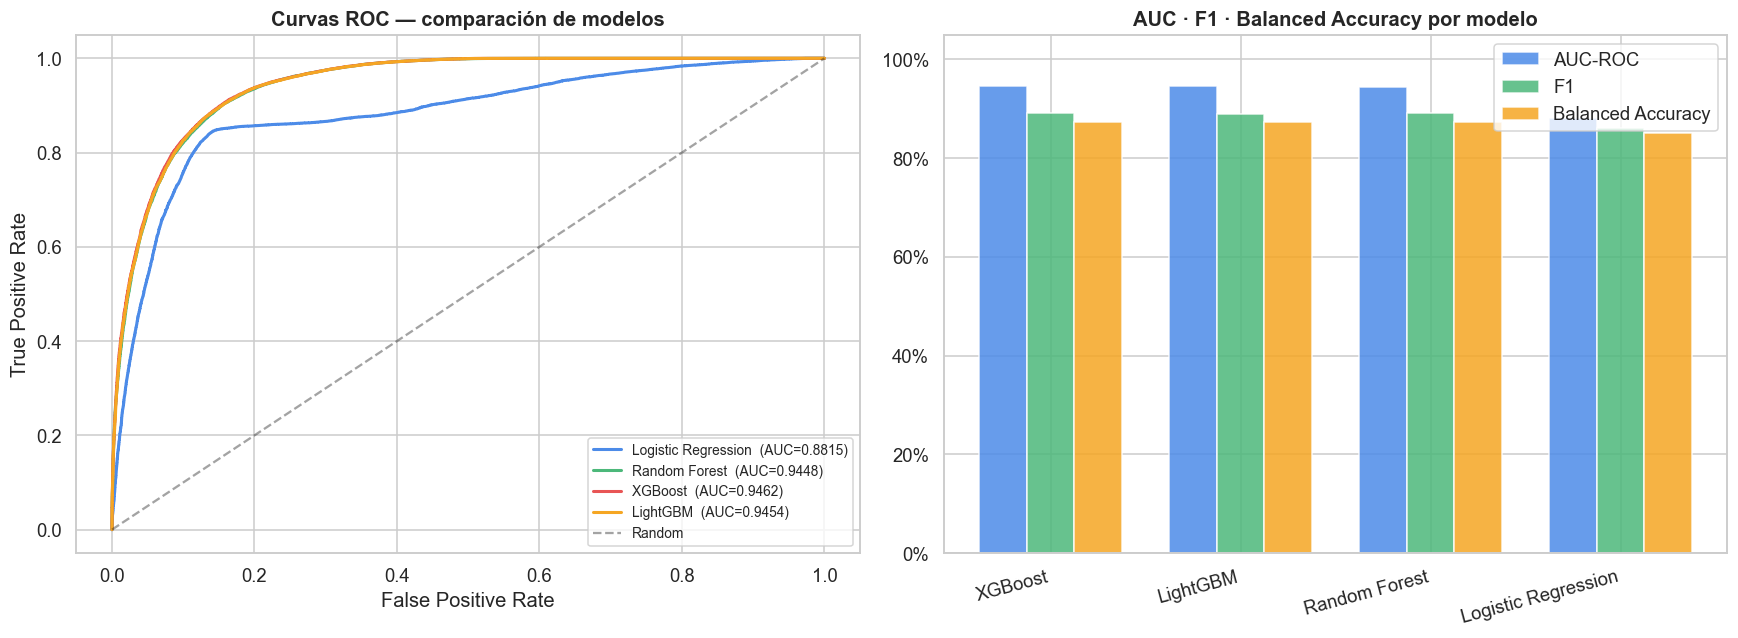

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Curvas ROC ────────────────────────────────────────────────────────────────
ax = axes[0]
roc_data = [
    ('Logistic Regression', lr_prob,  '#4c8be8'),
    ('Random Forest',       rf_prob,  '#4cb87a'),
    ('XGBoost',             xgb_prob, '#e85555'),
    ('LightGBM',            lgb_prob, '#f5a623'),
]
for name, prob, color in roc_data:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name}  (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Curvas ROC — comparación de modelos', fontweight='bold')
ax.legend(fontsize=9)

# ── Barras AUC ────────────────────────────────────────────────────────────────
ax2 = axes[1]
metrics_to_plot = df_results[['AUC-ROC', 'F1', 'Balanced Accuracy']]
x = np.arange(len(metrics_to_plot))
width = 0.25
colors_bar = ['#4c8be8', '#4cb87a', '#f5a623']
for i, (col, color) in enumerate(zip(metrics_to_plot.columns, colors_bar)):
    bars = ax2.bar(x + i * width, metrics_to_plot[col], width, label=col, color=color, alpha=0.85, edgecolor='white')

ax2.set_xticks(x + width)
ax2.set_xticklabels(metrics_to_plot.index, rotation=15, ha='right')
ax2.set_ylim(0, 1.05)
ax2.set_title('AUC · F1 · Balanced Accuracy por modelo', fontweight='bold')
ax2.legend()
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1))

plt.tight_layout()
plt.show()

## Matriz de confusión — mejor modelo

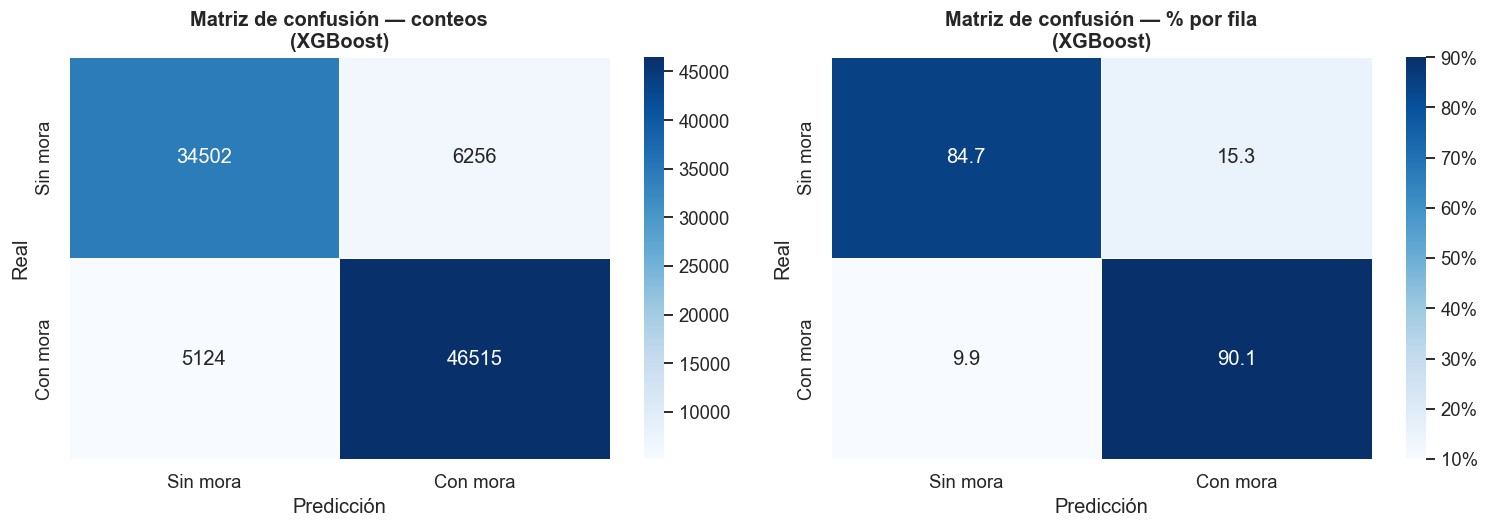


Classification report — XGBoost:
              precision    recall  f1-score   support

    Sin mora       0.87      0.85      0.86     40758
    Con mora       0.88      0.90      0.89     51639

    accuracy                           0.88     92397
   macro avg       0.88      0.87      0.87     92397
weighted avg       0.88      0.88      0.88     92397



In [12]:
best_pred_map = {
    'Logistic Regression': lr_pred,
    'Random Forest':       rf_pred,
    'XGBoost':             xgb_pred,
    'LightGBM':            lgb_pred,
}
best_pred = best_pred_map[best_model_name]

cm = confusion_matrix(y_test, best_pred)
cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, data, fmt, title in [
    (axes[0], cm,     'd',    'Matriz de confusión — conteos'),
    (axes[1], cm_pct, '.1f',  'Matriz de confusión — % por fila'),
]:
    sns.heatmap(
        data, annot=True, fmt=fmt, cmap='Blues',
        xticklabels=['Sin mora', 'Con mora'],
        yticklabels=['Sin mora', 'Con mora'],
        linewidths=0.5, ax=ax,
        cbar_kws={'format': '%.0f%%' if '%' in title else None},
    )
    ax.set_xlabel('Predicción')
    ax.set_ylabel('Real')
    ax.set_title(f'{title}\n({best_model_name})', fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nClassification report — {best_model_name}:')
print(classification_report(y_test, best_pred, target_names=['Sin mora', 'Con mora']))

## Feature Importance — mejor modelo

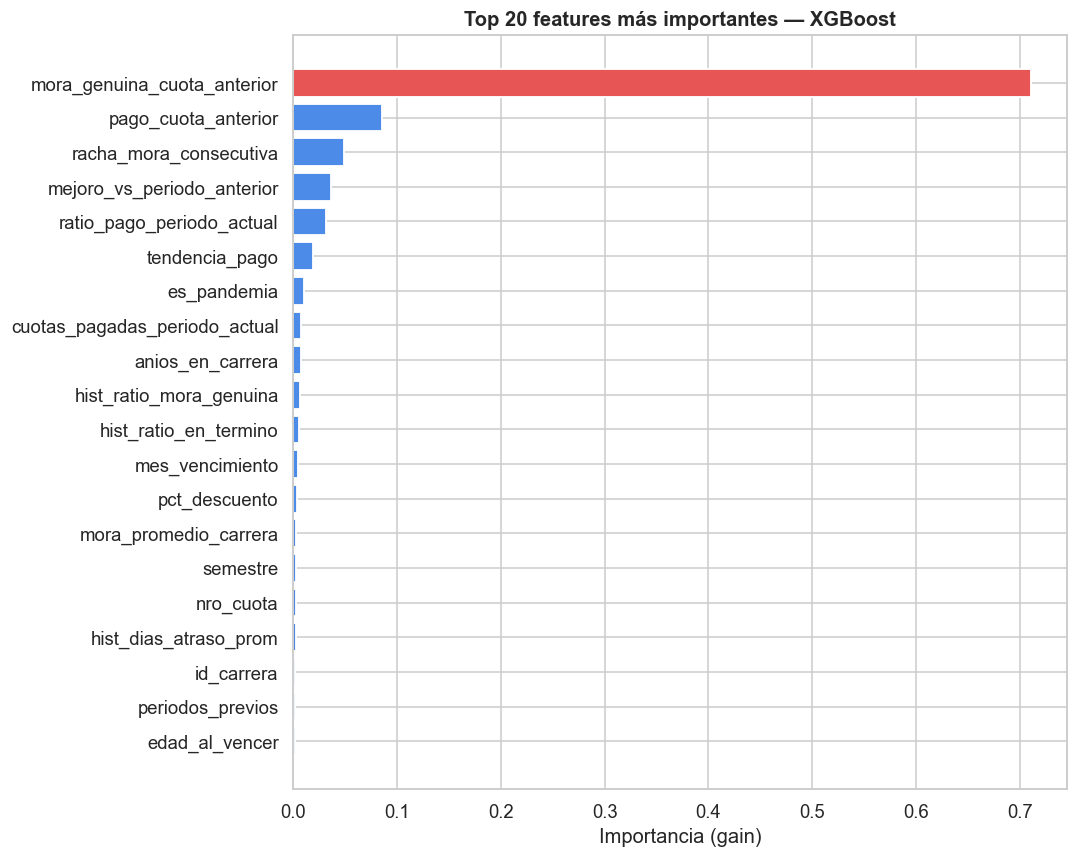

In [13]:
fig, ax = plt.subplots(figsize=(10, 8))

if best_model_name == 'Logistic Regression':
    coefs = np.abs(pipe_lr.named_steps['clf'].coef_[0])
    imp = pd.Series(coefs, index=features_exist).sort_values(ascending=False).head(20)
    xlabel = 'Coeficiente |LR| (normalizado)'

elif best_model_name == 'Random Forest':
    imp = pd.Series(
        pipe_rf.named_steps['clf'].feature_importances_,
        index=features_exist
    ).sort_values(ascending=False).head(20)
    xlabel = 'Importancia (Gini)'

elif best_model_name == 'XGBoost':
    imp = pd.Series(
        model_xgb.feature_importances_,
        index=features_exist
    ).sort_values(ascending=False).head(20)
    xlabel = 'Importancia (gain)'

else:  # LightGBM
    imp = pd.Series(
        model_lgb.feature_importances_,
        index=features_exist
    ).sort_values(ascending=False).head(20)
    xlabel = 'Importancia (split)'

colors = ['#e85555' if v == imp.max() else '#4c8be8' for v in imp.values]
ax.barh(imp.index[::-1], imp.values[::-1], color=colors[::-1], edgecolor='white', linewidth=1.2)
ax.set_xlabel(xlabel)
ax.set_title(f'Top 20 features más importantes — {best_model_name}', fontweight='bold')
plt.tight_layout()
plt.show()

## Robustez de la validación

Esta sección compara tres estrategias de validación sobre el mismo baseline para medir cuánto optimismo introduce el split aleatorio por filas:

- **Aleatorio por filas**: mezcla cuotas del mismo alumno entre train y test.
- **Por alumno**: ningún `id_alumno` aparece en ambos conjuntos.
- **Temporal**: entrena con períodos anteriores y prueba en períodos futuros.

Usamos **Logistic Regression** porque es rápida, estable e interpretable como baseline metodológico.

In [14]:
from sklearn.model_selection import GroupShuffleSplit

# Re-armamos X/y de forma autocontenida para comparar protocolos de validación
X_eval = df[features_exist].copy()
y_eval = df[TARGET].astype(int)
X_eval['id_carrera'] = LabelEncoder().fit_transform(
    X_eval['id_carrera'].astype(str).str.strip()
)


def fit_eval_lr(X_train, X_test, y_train, y_test, label):
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(
            max_iter=500,
            class_weight='balanced',
            solver='saga',
            n_jobs=-1,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    prob = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    return {
        'Protocolo': label,
        'AUC-ROC': roc_auc_score(y_test, prob),
        'F1': f1_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall': recall_score(y_test, pred),
        'Balanced Accuracy': balanced_accuracy_score(y_test, pred),
        'Train filas': len(X_train),
        'Test filas': len(X_test),
        'Train alumnos': int(df.loc[X_train.index, 'id_alumno'].nunique()),
        'Test alumnos': int(df.loc[X_test.index, 'id_alumno'].nunique()),
    }


validation_rows = []

# 1) Split aleatorio por filas
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_eval, y_eval,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_eval,
)
validation_rows.append(
    fit_eval_lr(X_train_r, X_test_r, y_train_r, y_test_r, 'Aleatorio por filas')
)

# 2) Split por alumno
splitter = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
train_idx_g, test_idx_g = next(splitter.split(X_eval, y_eval, groups=df['id_alumno']))
X_train_g, X_test_g = X_eval.iloc[train_idx_g], X_eval.iloc[test_idx_g]
y_train_g, y_test_g = y_eval.iloc[train_idx_g], y_eval.iloc[test_idx_g]
validation_rows.append(
    fit_eval_lr(X_train_g, X_test_g, y_train_g, y_test_g, 'Split por alumno')
)

# 3) Split temporal
mask_train_t = df['periodo'] <= 2023
mask_test_t = df['periodo'] >= 2024
X_train_t, X_test_t = X_eval.loc[mask_train_t], X_eval.loc[mask_test_t]
y_train_t, y_test_t = y_eval.loc[mask_train_t], y_eval.loc[mask_test_t]
validation_rows.append(
    fit_eval_lr(X_train_t, X_test_t, y_train_t, y_test_t, 'Split temporal 2020-2023 vs 2024-2025')
)

df_validation = pd.DataFrame(validation_rows).set_index('Protocolo')

shared_students = len(
    set(df.loc[X_train_r.index, 'id_alumno']) & set(df.loc[X_test_r.index, 'id_alumno'])
)
pct_test_seen = shared_students / df.loc[X_test_r.index, 'id_alumno'].nunique() * 100
print(f'Alumnos del test aleatorio también vistos en train: {pct_test_seen:.2f}%')

display(
    df_validation[['AUC-ROC', 'F1', 'Precision', 'Recall', 'Balanced Accuracy']]
    .sort_values('AUC-ROC', ascending=False)
    .style.highlight_max(
        axis=0,
        props='background-color: #1b5e20; color: #ffffff; font-weight: 600',
    )
    .format('{:.4f}')
)

Alumnos del test aleatorio también vistos en train: 99.98%


,AUC-ROC,F1,Precision,Recall,Balanced Accuracy
Protocolo,,,,,
Aleatorio por filas,0.8815,0.8620,0.8867,0.8386,0.8514
Split por alumno,0.8794,0.8583,0.8834,0.8346,0.8493
Split temporal 2020-2023 vs 2024-2025,0.8636,0.8230,0.8613,0.7879,0.8309


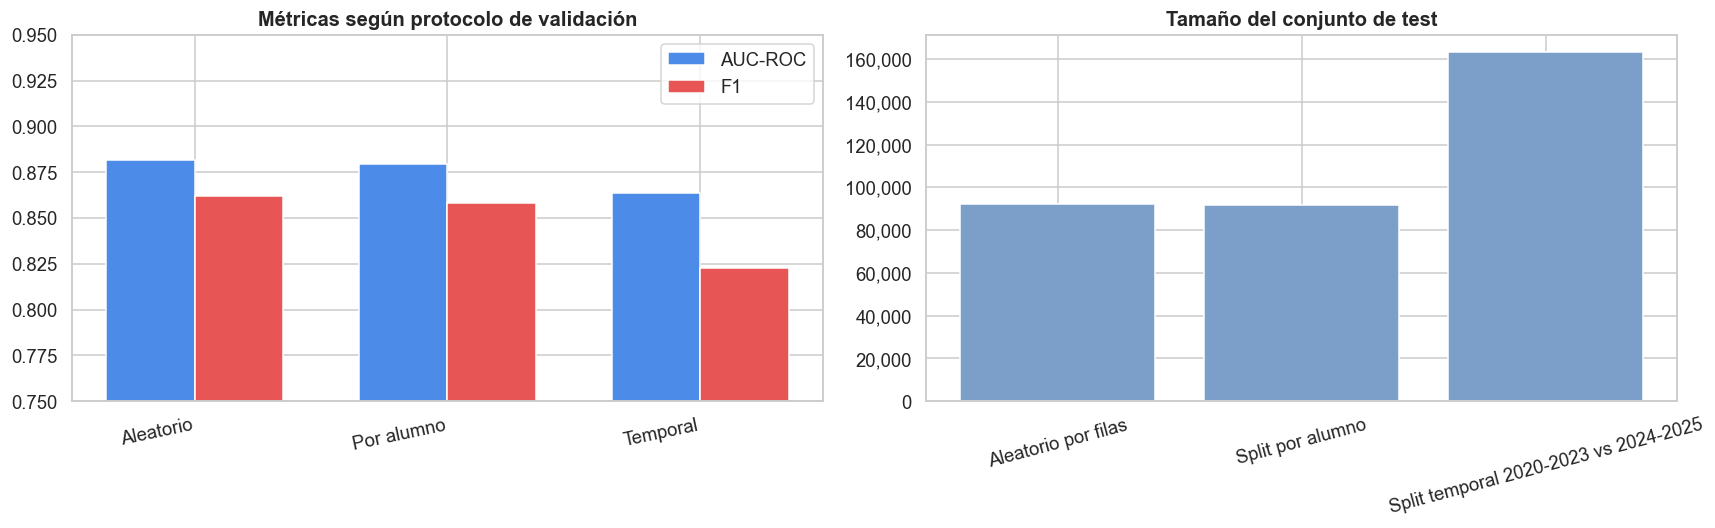

Lectura sugerida:
- Si el split aleatorio supera claramente al temporal, hay optimismo por mezcla de contextos.
- Si el split por alumno baja mucho, el modelo depende de patrones históricos muy específicos del estudiante.
- El split temporal suele ser la referencia más realista para estimar desempeño futuro.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Comparación AUC y F1 por protocolo
plot_df = df_validation[['AUC-ROC', 'F1']].copy()
plot_df = plot_df.loc[
    ['Aleatorio por filas', 'Split por alumno', 'Split temporal 2020-2023 vs 2024-2025']
]

x = np.arange(len(plot_df))
width = 0.35
axes[0].bar(x - width/2, plot_df['AUC-ROC'], width, label='AUC-ROC', color='#4c8be8', edgecolor='white')
axes[0].bar(x + width/2, plot_df['F1'], width, label='F1', color='#e85555', edgecolor='white')
axes[0].set_xticks(x)
axes[0].set_xticklabels(['Aleatorio', 'Por alumno', 'Temporal'], rotation=12, ha='right')
axes[0].set_ylim(0.75, 0.95)
axes[0].set_title('Métricas según protocolo de validación', fontweight='bold')
axes[0].legend()

# Tamaño de test por protocolo
sizes = df_validation['Test filas'].copy()
axes[1].bar(df_validation.index, sizes, color='#7b9fc9', edgecolor='white')
axes[1].set_title('Tamaño del conjunto de test', fontweight='bold')
axes[1].tick_params(axis='x', rotation=15)
axes[1].yaxis.set_major_formatter(mticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

print('Lectura sugerida:')
print('- Si el split aleatorio supera claramente al temporal, hay optimismo por mezcla de contextos.')
print('- Si el split por alumno baja mucho, el modelo depende de patrones históricos muy específicos del estudiante.')
print('- El split temporal suele ser la referencia más realista para estimar desempeño futuro.')

## Experimento 1: ¿Modelo perezoso?

Se entrena **XGBoost con split temporal (2020-2023 → 2024-2025)** en dos variantes:

- **Full**: incluye `pago_cuota_anterior` y `mora_genuina_cuota_anterior` (predictores dominantes).
- **Sin dominantes**: esas dos features se eliminan; el modelo debe buscar patrones más profundos.

Si el AUC cae mucho al eliminarlas, confirma que el modelo 'perezoso' depende casi exclusivamente del estado del mes anterior.

In [16]:
DOMINANT = ['pago_cuota_anterior', 'mora_genuina_cuota_anterior']

# ── Preparar datos ────────────────────────────────────────────────────────
mask_tr = df['periodo'] <= 2023
mask_te = df['periodo'] >= 2024

def _prep_xgb(feats):
    X_ = df[feats].copy()
    X_['id_carrera'] = LabelEncoder().fit_transform(X_['id_carrera'].astype(str).str.strip())
    imp = SimpleImputer(strategy='median', keep_empty_features=True)
    Xtr = imp.fit_transform(X_.loc[mask_tr])
    Xte = imp.transform(X_.loc[mask_te])
    return Xtr, Xte

feats_full = features_exist
feats_nd   = [f for f in features_exist if f not in DOMINANT]

y_tr = df.loc[mask_tr, TARGET].astype(int)
y_te = df.loc[mask_te, TARGET].astype(int)

Xtr_full, Xte_full = _prep_xgb(feats_full)
Xtr_nd,   Xte_nd   = _prep_xgb(feats_nd)

# ── Entrenar ambas variantes ───────────────────────────────────────────────
def _train_xgb(Xtr, ytr):
    spw = (ytr == 0).sum() / (ytr == 1).sum()
    m = xgb.XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.05,
        scale_pos_weight=spw, subsample=0.8, colsample_bytree=0.8,
        eval_metric='auc', n_jobs=-1,
        random_state=RANDOM_STATE, verbosity=0,
    )
    m.fit(Xtr, ytr)
    return m

m_full = _train_xgb(Xtr_full, y_tr)
m_nd   = _train_xgb(Xtr_nd,   y_tr)

# ── Métricas ──────────────────────────────────────────────────────────────
from sklearn.metrics import roc_auc_score, f1_score, recall_score, precision_score

def _metrics(m, Xte, yte, label):
    prob = m.predict_proba(Xte)[:, 1]
    pred = m.predict(Xte)
    return {
        'Variante': label,
        'AUC-ROC':   round(roc_auc_score(yte, prob), 4),
        'F1':        round(f1_score(yte, pred), 4),
        'Precision': round(precision_score(yte, pred), 4),
        'Recall':    round(recall_score(yte, pred), 4),
        'n_features': Xte.shape[1],
    }

rows_nd = [
    _metrics(m_full, Xte_full, y_te, f'Con dominantes ({len(feats_full)} features)'),
    _metrics(m_nd,   Xte_nd,   y_te, f'Sin dominantes ({len(feats_nd)} features)'),
]
df_nd = pd.DataFrame(rows_nd).set_index('Variante')

delta_auc = df_nd.loc[df_nd.index[1], 'AUC-ROC'] - df_nd.loc[df_nd.index[0], 'AUC-ROC']
print(f'Delta AUC al eliminar predictores dominantes: {delta_auc:+.4f}')
if abs(delta_auc) < 0.02:
    print('→ Caída pequeña: el modelo tiene señal genuina más allá del mes anterior.')
else:
    print('→ Caída significativa: parte del poder predictivo depende del predictor dominante.')

display(
    df_nd[['AUC-ROC', 'F1', 'Precision', 'Recall']]
    .style
    .highlight_max(axis=0, props='background-color: #1b5e20; color: #fff; font-weight:600')
    .format('{:.4f}', subset=['AUC-ROC','F1','Precision','Recall'])
)

# Guardar para comparación posterior
xgb_temporal_full  = m_full
xgb_temporal_nd    = m_nd
Xte_temporal_full  = Xte_full
Xte_temporal_nd    = Xte_nd
y_te_temporal      = y_te
prob_temporal_full = m_full.predict_proba(Xte_full)[:, 1]
pred_temporal_full = m_full.predict(Xte_full)
print('\nModelos guardados en xgb_temporal_full y xgb_temporal_nd')

Delta AUC al eliminar predictores dominantes: -0.0037
→ Caída pequeña: el modelo tiene señal genuina más allá del mes anterior.


,AUC-ROC,F1,Precision,Recall
Variante,,,,
Con dominantes (27 features),0.9269,0.8474,0.8509,0.8440
Sin dominantes (25 features),0.9232,0.8413,0.8538,0.8291



Modelos guardados en xgb_temporal_full y xgb_temporal_nd


## Experimento 2: Contexto macroeconómico (inflación Argentina)

Se agrega `inflacion_anual_pct` como feature: tasa de inflación anual del año correspondiente a cada cuota.

| Año | IPC anual (aprox.) | Contexto |
|-----|--------------------|----------|
| 2020 | 36 % | Pandemia, cuarentena |
| 2021 | 51 % | Recuperación |
| 2022 | 95 % | Crisis cambiaria |
| 2023 | 211 % | Hiperinflación electoral |
| 2024 | 118 % | Ajuste fiscal — shock inicial |
| 2025 | 38 % | Estabilización |

Esto permite que el modelo distinga 'mora por costumbre' de 'mora por crisis económica'.

In [17]:
# Inflación oficial Argentina por año (INDEC / estimaciones consenso)
IPC_ARG = {
    2020: 36.1,
    2021: 50.9,
    2022: 94.8,
    2023: 211.4,
    2024: 117.8,
    2025: 38.0,
}

df_macro = df.copy()
df_macro['inflacion_anual_pct'] = df_macro['periodo'].map(IPC_ARG).fillna(50.0)

feats_macro = feats_full + ['inflacion_anual_pct']

X_m = df_macro[feats_macro].copy()
X_m['id_carrera'] = LabelEncoder().fit_transform(X_m['id_carrera'].astype(str).str.strip())
imp_m = SimpleImputer(strategy='median', keep_empty_features=True)
Xtr_m = imp_m.fit_transform(X_m.loc[mask_tr])
Xte_m = imp_m.transform(X_m.loc[mask_te])

m_macro = _train_xgb(Xtr_m, y_tr)
prob_macro = m_macro.predict_proba(Xte_m)[:, 1]
pred_macro = m_macro.predict(Xte_m)

res_macro = pd.DataFrame([
    _metrics(m_full,  Xte_full, y_te, 'Sin macro (baseline temporal)'),
    {'Variante': f'Con inflacion_anual_pct ({len(feats_macro)} features)',
     'AUC-ROC':   round(roc_auc_score(y_te, prob_macro), 4),
     'F1':        round(f1_score(y_te, pred_macro), 4),
     'Precision': round(precision_score(y_te, pred_macro), 4),
     'Recall':    round(recall_score(y_te, pred_macro), 4),
     'n_features': Xte_m.shape[1]},
]).set_index('Variante')

display(
    res_macro[['AUC-ROC','F1','Precision','Recall']]
    .style
    .highlight_max(axis=0, props='background-color: #1b5e20; color: #fff; font-weight:600')
    .format('{:.4f}', subset=['AUC-ROC','F1','Precision','Recall'])
)

# Importancia de la feature macro
feat_names_m = feats_macro.copy()
feat_names_m[feat_names_m.index('id_carrera')] = 'id_carrera'
fi_macro = pd.Series(m_macro.feature_importances_, index=feat_names_m)
macro_rank = fi_macro.rank(ascending=False).loc['inflacion_anual_pct']
print(f'\nRanking de inflacion_anual_pct en importancias: #{int(macro_rank)} de {len(feat_names_m)}')

,AUC-ROC,F1,Precision,Recall
Variante,,,,
Sin macro (baseline temporal),0.9269,0.8474,0.8509,0.8440
Con inflacion_anual_pct (28 features),0.9262,0.8530,0.8429,0.8634



Ranking de inflacion_anual_pct en importancias: #6 de 28


In [18]:
df_macro

,id_alumno,id_persona,periodo,nro_cuota,fecha_vencimiento,id_carrera,id_sede_academica,id_unidad_academica,id_facultad,id_categoria_arancelaria,...,tendencia_pago,mejoro_vs_periodo_anterior,mora_promedio_carrera,mora_promedio_cohorte,mora_vs_cohorte,es_ultimo_anio_esperado,cuotas_pagadas_periodo_actual,cuotas_vistas_periodo_actual,ratio_pago_periodo_actual,inflacion_anual_pct
0,66,66,2023,1,2023-03-15,18,1,3,I,2198,...,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,0,-1.0,211.4
1,66,66,2023,2,2023-04-15,18,1,3,I,2198,...,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,1,0.0,211.4
2,66,66,2023,3,2023-05-15,18,1,3,I,2198,...,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,2,0.0,211.4
3,66,66,2023,4,2023-06-15,18,1,3,I,2198,...,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,3,0.0,211.4
4,66,66,2023,5,2023-07-15,18,1,3,I,2198,...,NaN,-1.0,0.669133,0.0,NaN,-1.0,0.0,4,0.0,211.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461979,1251841,2070866,2025,7,2025-09-15,34,2,5,P,2198,...,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,6,0.0,38.0
461980,1251841,2070866,2025,8,2025-10-15,34,2,5,P,2198,...,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,7,0.0,38.0
461981,1251841,2070866,2025,9,2025-11-15,34,2,5,P,2198,...,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,8,0.0,38.0
461982,1251841,2070866,2025,10,2025-12-15,34,2,5,P,2198,...,NaN,-1.0,0.599664,NaN,NaN,-1.0,0.0,9,0.0,38.0


## Análisis de Error por Carrera

Se calcula el **AUC-ROC por `id_carrera`** sobre el conjunto de test temporal (2024-2025).

Esto revela si el modelo es sistemáticamente peor en alguna facultad, lo que puede indicar patrones de pago distintos que merecen un modelo especializado.

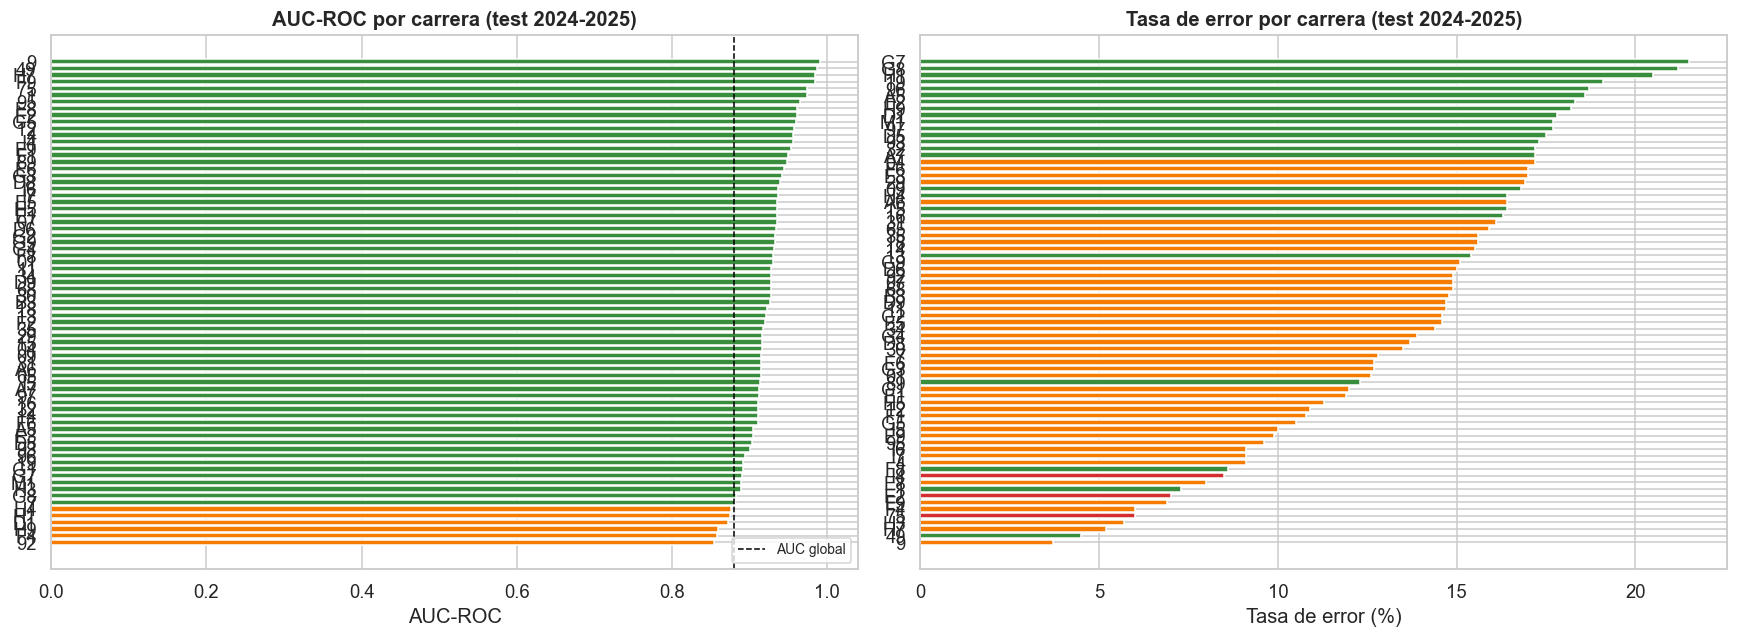


--- Carreras con PEOR AUC (candidatas a modelo propio) ---
            n_cuotas  mora_real_%  AUC-ROC  Recall  Error_%
id_carrera                                                 
92                67         67.2   0.8535  0.9556     14.9
F4                83         73.5   0.8573  0.9836      6.0
H9               336         64.0   0.8589  0.8744     18.2

--- Carreras con MEJOR AUC ---
            n_cuotas  mora_real_%  AUC-ROC  Recall  Error_%
id_carrera                                                 
9                108         47.2   0.9904  0.9608      3.7
49               515         11.8   0.9869  0.9016      4.5
H7                96         36.5   0.9845  1.0000      5.2


In [19]:
# Tomar predicciones del modelo temporal completo
df_te = df.loc[mask_te, ['id_carrera', TARGET]].copy()
df_te['prob']  = prob_temporal_full
df_te['pred']  = pred_temporal_full
df_te['error'] = (df_te['pred'] != df_te[TARGET].astype(int)).astype(int)

career_stats = []
for carrera, grp in df_te.groupby('id_carrera'):
    if len(grp) < 50 or grp[TARGET].nunique() < 2:
        continue
    auc_c  = roc_auc_score(grp[TARGET].astype(int), grp['prob'])
    rec_c  = recall_score(grp[TARGET].astype(int), grp['pred'])
    prec_c = precision_score(grp[TARGET].astype(int), grp['pred'])
    err_c  = grp['error'].mean()
    career_stats.append({
        'id_carrera': carrera,
        'n_cuotas': len(grp),
        'mora_real_%': round(grp[TARGET].mean() * 100, 1),
        'AUC-ROC':   round(auc_c, 4),
        'Recall':    round(rec_c, 4),
        'Precision': round(prec_c, 4),
        'Error_%':   round(err_c * 100, 1),
    })

df_career = pd.DataFrame(career_stats).set_index('id_carrera').sort_values('AUC-ROC')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# AUC por carrera
colors_auc = ['#d32f2f' if v < 0.80 else '#f57c00' if v < 0.88 else '#388e3c'
              for v in df_career['AUC-ROC']]
axes[0].barh(df_career.index.astype(str), df_career['AUC-ROC'],
             color=colors_auc, edgecolor='white')
axes[0].axvline(0.88, color='black', linestyle='--', linewidth=1, label='AUC global')
axes[0].set_xlabel('AUC-ROC')
axes[0].set_title('AUC-ROC por carrera (test 2024-2025)', fontweight='bold')
axes[0].legend(fontsize=9)

# Error % por carrera
colors_err = ['#d32f2f' if v > 20 else '#f57c00' if v > 12 else '#388e3c'
              for v in df_career['Error_%']]
axes[1].barh(df_career.sort_values('Error_%').index.astype(str),
             df_career.sort_values('Error_%')['Error_%'],
             color=colors_err, edgecolor='white')
axes[1].set_xlabel('Tasa de error (%)')
axes[1].set_title('Tasa de error por carrera (test 2024-2025)', fontweight='bold')

plt.tight_layout()
plt.show()

worst = df_career.nsmallest(3, 'AUC-ROC')
best  = df_career.nlargest(3, 'AUC-ROC')
print('\n--- Carreras con PEOR AUC (candidatas a modelo propio) ---')
print(worst[['n_cuotas','mora_real_%','AUC-ROC','Recall','Error_%']].to_string())
print('\n--- Carreras con MEJOR AUC ---')
print(best[['n_cuotas','mora_real_%','AUC-ROC','Recall','Error_%']].to_string())

## Umbral de Decisión — Métrica de Negocio

El threshold por defecto (0.5) maximiza F1 pero **ignora el costo asimétrico**:

| Error | Significado | Costo |
|-------|------------|-------|
| **Falso Negativo** (predice paga, mora) | La universidad no actúa → pierde la cuota | **Alto** |
| **Falso Positivo** (predice mora, paga) | Llamado/aviso innecesario → desgaste administrativo | **Bajo** |

Ajustando el umbral se puede priorizar **Recall** (capturar más morosos reales) a costa de más alertas falsas. La universidad define el ratio `costo_FN / costo_FP`.

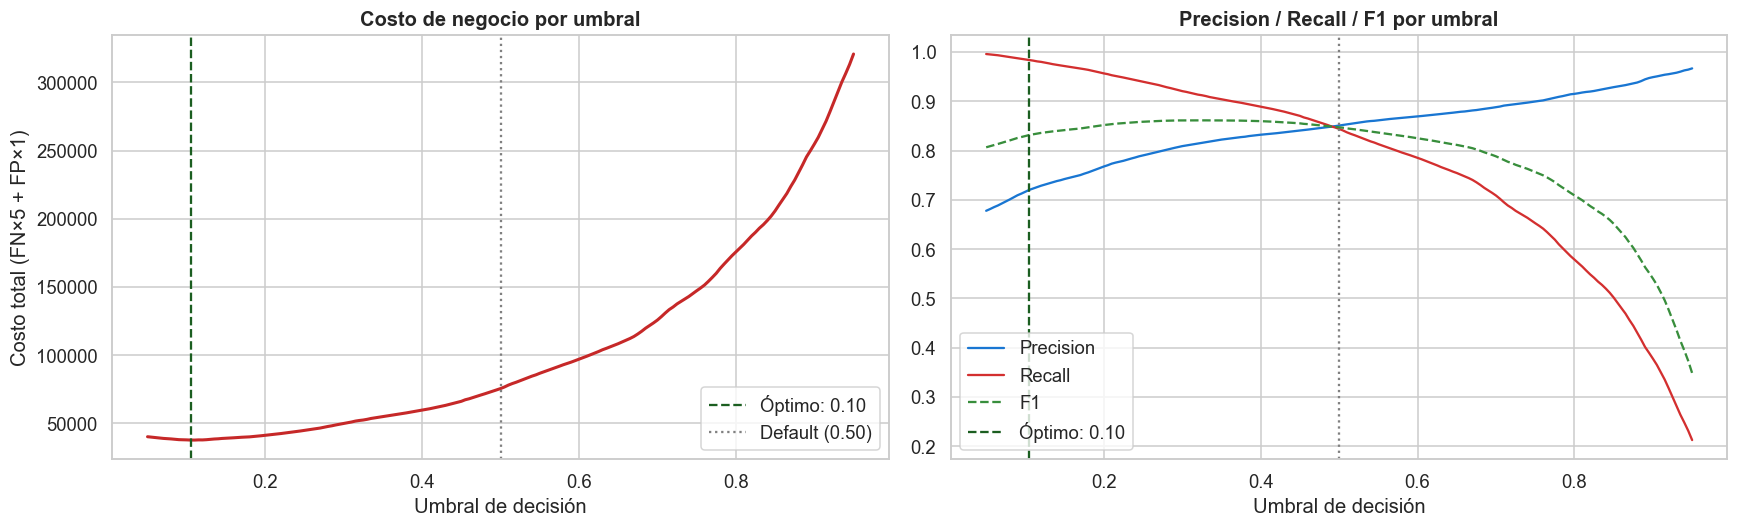

Umbral DEFAULT (0.50):
  Recall=0.844  Precision=0.851  F1=0.847  FN=12,687  FP=12,025

Umbral ÓPTIMO (0.10) — minimiza costo FN×5+FP×1:
  Recall=0.984  Precision=0.720  F1=0.832  FN=1,322  FP=31,071

→ Ajustando el umbral se capturan 11,365 morosos adicionales a costa de 19,046 alertas extra.


In [20]:
COST_FN = 5   # perder una cuota ~5x más caro que un aviso administrativo
COST_FP = 1

thresholds = np.linspace(0.05, 0.95, 181)
records = []
for thr in thresholds:
    pred_t = (prob_temporal_full >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_te_temporal, pred_t).ravel()
    records.append({
        'threshold': thr,
        'cost':      fn * COST_FN + fp * COST_FP,
        'F1':        f1_score(y_te_temporal, pred_t, zero_division=0),
        'Recall':    recall_score(y_te_temporal, pred_t, zero_division=0),
        'Precision': precision_score(y_te_temporal, pred_t, zero_division=0),
        'FN': fn, 'FP': fp,
    })

df_thr = pd.DataFrame(records)
opt_row = df_thr.loc[df_thr['cost'].idxmin()]
default_row = df_thr.iloc[(df_thr['threshold'] - 0.5).abs().idxmin()]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Curva de costo
axes[0].plot(df_thr['threshold'], df_thr['cost'], color='#c62828', linewidth=2)
axes[0].axvline(opt_row['threshold'], color='#1b5e20', linestyle='--',
               label=f"Óptimo: {opt_row['threshold']:.2f}")
axes[0].axvline(0.5, color='grey', linestyle=':', label='Default (0.50)')
axes[0].set_xlabel('Umbral de decisión')
axes[0].set_ylabel(f'Costo total (FN×{COST_FN} + FP×{COST_FP})')
axes[0].set_title('Costo de negocio por umbral', fontweight='bold')
axes[0].legend()

# Precision / Recall
axes[1].plot(df_thr['threshold'], df_thr['Precision'], label='Precision', color='#1976d2')
axes[1].plot(df_thr['threshold'], df_thr['Recall'],    label='Recall',    color='#d32f2f')
axes[1].plot(df_thr['threshold'], df_thr['F1'],        label='F1',        color='#388e3c',
             linestyle='--')
axes[1].axvline(opt_row['threshold'], color='#1b5e20', linestyle='--',
               label=f"Óptimo: {opt_row['threshold']:.2f}")
axes[1].axvline(0.5, color='grey', linestyle=':')
axes[1].set_xlabel('Umbral de decisión')
axes[1].set_title('Precision / Recall / F1 por umbral', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f'Umbral DEFAULT (0.50):')
print(f'  Recall={default_row["Recall"]:.3f}  Precision={default_row["Precision"]:.3f}'
      f'  F1={default_row["F1"]:.3f}  FN={int(default_row["FN"]):,}  FP={int(default_row["FP"]):,}')
print(f'\nUmbral ÓPTIMO ({opt_row["threshold"]:.2f}) — minimiza costo FN×{COST_FN}+FP×{COST_FP}:')
print(f'  Recall={opt_row["Recall"]:.3f}  Precision={opt_row["Precision"]:.3f}'
      f'  F1={opt_row["F1"]:.3f}  FN={int(opt_row["FN"]):,}  FP={int(opt_row["FP"]):,}')
fn_saved = int(default_row['FN']) - int(opt_row['FN'])
fp_added = int(opt_row['FP']) - int(default_row['FP'])
print(f'\n→ Ajustando el umbral se capturan {fn_saved:,} morosos adicionales'
      f' a costa de {fp_added:,} alertas extra.')

## Experimento 5: Rendimiento académico (estado de materias)

Se incorporan features derivadas de `alumno_asignatura`: el porcentaje de materias en estados "críticos" (no Regulares ni Aprobadas) como proxy del compromiso y trayectoria académica del alumno.

| Estado | Código | ¿Es crítico para pagos? |
|--------|--------|-------------------------|
| Regular | 2 | No |
| Aprobada | 3 | No |
| Inscripto | 1 | Sí |
| C | 4 | Sí |
| T | 5 | Sí |
| Vencida | 6 | Sí |
| P | 10 | Sí |
| Libre | 11 | Sí |

**Features nuevas generadas (por alumno):**
- `n_materias_total` — cantidad total de materias registradas
- `pct_aprobadas` — % materias con estado = 3 (Aprobada)
- `pct_regulares` — % materias con estado = 2 (Regular)
- `pct_vencidas` — % materias con estado = 6 (Vencida)
- `pct_criticas` — % materias en estado **NO** Regular ni Aprobada

**Hipótesis:** alumnos con alta proporción de materias vencidas o en estados críticos tienen mayor probabilidad de mora arancelaria — el rezago o abandono académico correlaciona con dificultades económicas de pago.

> ⚠️ **Limitación:** `alumno_asignatura` refleja el estado actual de las materias, no el histórico por período. Para el split temporal esto introduce cierta contaminación temporal; se usa como baseline exploratorio pendiente de versión con snapshot histórico.

Conexion OK -> eUNSTAv3

--- Estructura de alumno_asignatura ---


,Field,Type,Null,Key,Default,Extra
0,id_alumno_asignatura,int(11),NO,PRI,NaN,auto_increment
1,id_alumno,int(11),YES,MUL,NaN,
2,id_asignatura,int(11),YES,MUL,0,
3,periodo,int(11),YES,,NaN,
4,id_cuatrimestre,int(11),YES,,NaN,
5,id_comision,int(11),YES,,NaN,
6,id_comision_practica,int(11),YES,,NaN,
7,id_equivalencia,int(11),YES,,NaN,
8,estado,int(11),YES,MUL,NaN,
9,id_examen,int(11),YES,,NaN,



asignatura: ['id_asignatura', 'descripcion', 'descripcion_analitico', 'abreviatura', 'hs_dis_totales', 'hs_dis_semanal', 'id_cuatrimestre', 'id_tipo_division', 'dfhc', 'id_tipo_regimen', 'id_plan', 'vigente', 'descripcion_alter', 'id_area', 'id_departamento', 'id_disciplina', 'id_grupo', 'nro_resol_ministerial', 'nro_resol_rectoral', 'observaciones', 'dj_ambos_cuatri', 'id_optativa', 'extracurricular', 'idioma', 'credito', 'credito_diplo', 'creado']

planes_oe: ['id_plan_oe', 'id_oferta_educativa', 'plan', 'vigente', 'c_usuario', 'c_fecha', 'c_hora', 'id_unidad_academica', 'descripcion', 'ultimo_plan']

oferta_educativa: ['id_oferta_educativa', 'nombre', 'nombre_largo', 'abreviatura', 'id_carrera', 'diplomatura', 'id_titulo_oficial_sidcer', 'id_usuario', 'id_tipo_oe', 'id_oferta_sidcer', 'vigente', 'fecha_matricula', 'titulo', 'tipo', 'cant_cuotas', 'porcenta', 'ultilega', 'ultplan', 'duracion_regularidad', 'anio_duracion', 'categoria_base', 'impomatr', 'form_pago', 'direcarr', 'subin

,id_alumno,n_materias_total,n_aprobadas,n_regulares,n_vencidas,n_libres,n_criticas,pct_aprobadas,pct_regulares,pct_vencidas,pct_criticas
count,6.303400e+04,63035.000000,63035.000000,63035.000000,63035.000000,63035.000000,63035.000000,63035.000000,63035.000000,63035.000000,63035.000000
mean,9.621063e+05,37.004696,10.801475,0.318569,1.256318,2.297486,25.627429,0.304278,0.008405,0.035463,0.680979
std,2.816252e+06,12.944421,14.381504,1.294462,2.504847,3.048798,17.792430,0.386586,0.037902,0.075274,0.389956
min,1.000000e+00,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.779625e+04,34.000000,0.000000,0.000000,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.303000
50%,1.221214e+06,37.000000,2.000000,0.000000,0.000000,1.000000,30.000000,0.062000,0.000000,0.000000,0.913000
75%,1.237083e+06,44.000000,20.000000,0.000000,1.000000,4.000000,38.000000,0.648600,0.000000,0.042600,1.000000
max,1.001483e+08,163.000000,86.000000,29.000000,27.000000,87.000000,154.000000,1.000000,1.000000,1.000000,1.000000


Join carrera completa falló (posible schema distinto): Execution failed on sql '
SELECT
    aa.id_alumno,
    oe.id_carrera,
    oe.nombre                                              AS nombre_carrera,
    COUNT(DISTINCT aa.id_asignatura)                       AS n_materias_cursadas,
    COUNT(DISTINCT a.id_asignatura)                        AS n_materias_plan,
    ROUND(
        SUM(CASE WHEN aa.estado = 3 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(DISTINCT poe.id_asignatura), 0), 4
    )                                                      AS pct_avance_plan
FROM alumno_asignatura aa
JOIN asignatura a
    ON aa.id_asignatura = a.id_asignatura
JOIN planes_oe poe
    ON a.id_plan = poe.id_plan
JOIN oferta_educativa oe
    ON poe.id_oferta = oe.id_oferta
GROUP BY aa.id_alumno, oe.id_carrera, oe.nombre
': (pymysql.err.OperationalError) (1054, "Unknown column 'poe.id_asignatura' in 'field list'")
[SQL: 
SELECT
    aa.id_alumno,
    oe.id_carrera,
    oe.nombre                             

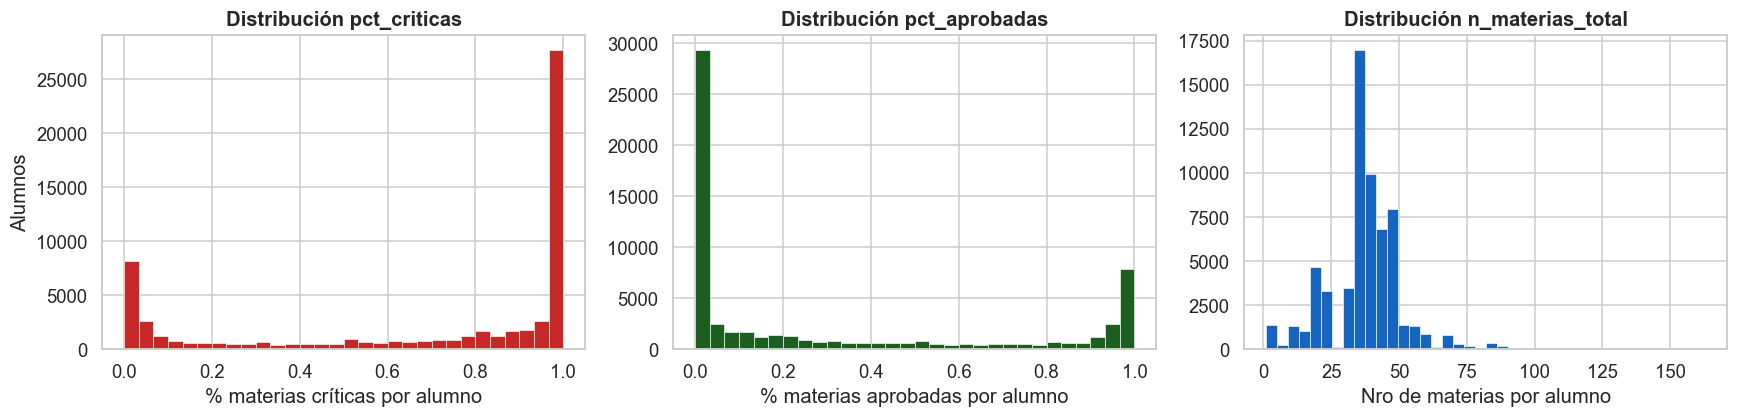


Estadísticas descriptivas del rendimiento académico:
       n_materias_total  pct_aprobadas  pct_regulares  pct_vencidas  \
count         63035.000      63035.000      63035.000     63035.000   
mean             37.005          0.304          0.008         0.035   
std              12.944          0.387          0.038         0.075   
min               1.000          0.000          0.000         0.000   
25%              34.000          0.000          0.000         0.000   
50%              37.000          0.062          0.000         0.000   
75%              44.000          0.649          0.000         0.043   
max             163.000          1.000          1.000         1.000   

       pct_criticas  
count     63035.000  
mean          0.681  
std           0.390  
min           0.000  
25%           0.303  
50%           0.913  
75%           1.000  
max           1.000  


In [21]:
# ── Conexión MySQL — igual patrón que eda_morosidad.ipynb ─────────────────────
import os
from pathlib import Path
from sqlalchemy import create_engine, text
from dotenv import load_dotenv

_env_path = Path.cwd().parent / '.env'
if _env_path.exists():
    load_dotenv(_env_path)
else:
    load_dotenv()

mysql_db = os.getenv('MYSQL_DATABASE') or os.getenv('MYSQL_DB')
required = {
    'MYSQL_HOST':     os.getenv('MYSQL_HOST'),
    'MYSQL_PORT':     os.getenv('MYSQL_PORT', '3306'),
    'MYSQL_USER':     os.getenv('MYSQL_USER'),
    'MYSQL_PASSWORD': os.getenv('MYSQL_PASSWORD'),
    'MYSQL_DATABASE': mysql_db,
}
missing = [k for k, v in required.items() if v is None or str(v).strip() == '']
if missing:
    raise ValueError(f"Faltan variables en .env: {', '.join(missing)}")

conn_str = (
    f"mysql+pymysql://{required['MYSQL_USER']}:{required['MYSQL_PASSWORD']}"
    f"@{required['MYSQL_HOST']}:{required['MYSQL_PORT']}/{required['MYSQL_DATABASE']}"
    f"?connect_timeout=30"
)
engine = create_engine(conn_str)
with engine.connect() as conn:
    conn.execute(text('SELECT 1'))
print(f"Conexion OK -> {required['MYSQL_DATABASE']}")

# ── Explorar estructura de tablas relevantes ──────────────────────────────────
print('\n--- Estructura de alumno_asignatura ---')
display(pd.read_sql(text('DESCRIBE alumno_asignatura'), engine))

for tbl in ['asignatura', 'planes_oe', 'oferta_educativa']:
    try:
        cols = pd.read_sql(text(f'DESCRIBE {tbl}'), engine)
        print(f"\n{tbl}: {cols['Field'].tolist()}")
    except Exception as e:
        print(f"\n{tbl}: ERROR -> {e}")

# ── Agregación académica por alumno ───────────────────────────────────────────
# Estado OK: 2=Regular, 3=Aprobada
# Estado Crítico: 1=Inscripto, 4=C, 5=T, 6=Vencida, 10=P, 11=Libre
q_academico = """
SELECT
    id_alumno,
    COUNT(*)                                               AS n_materias_total,
    SUM(CASE WHEN estado = 3 THEN 1 ELSE 0 END)           AS n_aprobadas,
    SUM(CASE WHEN estado = 2 THEN 1 ELSE 0 END)           AS n_regulares,
    SUM(CASE WHEN estado = 6 THEN 1 ELSE 0 END)           AS n_vencidas,
    SUM(CASE WHEN estado = 11 THEN 1 ELSE 0 END)          AS n_libres,
    SUM(CASE WHEN estado NOT IN (2,3) THEN 1 ELSE 0 END)  AS n_criticas,
    ROUND(SUM(CASE WHEN estado = 3 THEN 1 ELSE 0 END)
          / NULLIF(COUNT(*), 0), 4)                       AS pct_aprobadas,
    ROUND(SUM(CASE WHEN estado = 2 THEN 1 ELSE 0 END)
          / NULLIF(COUNT(*), 0), 4)                       AS pct_regulares,
    ROUND(SUM(CASE WHEN estado = 6 THEN 1 ELSE 0 END)
          / NULLIF(COUNT(*), 0), 4)                       AS pct_vencidas,
    ROUND(SUM(CASE WHEN estado NOT IN (2,3) THEN 1 ELSE 0 END)
          / NULLIF(COUNT(*), 0), 4)                       AS pct_criticas
FROM alumno_asignatura
GROUP BY id_alumno
"""
df_academico = pd.read_sql(text(q_academico), engine)
print(f"\nalumno_asignatura agregado: {len(df_academico):,} alumnos únicos")
display(df_academico.describe())

# ── Join con asignatura + planes_oe + oferta_educativa (carrera completa) ─────
# Exploratorio: materias por carrera para contextualizar el total del plan
q_materias_plan = """
SELECT
    aa.id_alumno,
    oe.id_carrera,
    oe.nombre                                              AS nombre_carrera,
    COUNT(DISTINCT aa.id_asignatura)                       AS n_materias_cursadas,
    COUNT(DISTINCT a.id_asignatura)                        AS n_materias_plan,
    ROUND(
        SUM(CASE WHEN aa.estado = 3 THEN 1 ELSE 0 END)
        / NULLIF(COUNT(DISTINCT poe.id_asignatura), 0), 4
    )                                                      AS pct_avance_plan
FROM alumno_asignatura aa
JOIN asignatura a
    ON aa.id_asignatura = a.id_asignatura
JOIN planes_oe poe
    ON a.id_plan = poe.id_plan
JOIN oferta_educativa oe
    ON poe.id_oferta = oe.id_oferta
GROUP BY aa.id_alumno, oe.id_carrera, oe.nombre
"""
try:
    df_plan = pd.read_sql(text(q_materias_plan), engine)
    print(f"\nJoin carrera completa: {len(df_plan):,} registros")
    display(df_plan.head())
    # Si hay duplicados por alumno (cursa dos carreras), quedarse con la principal
    df_plan = df_plan.sort_values('n_materias_cursadas', ascending=False)
    df_plan = df_plan.drop_duplicates(subset='id_alumno', keep='first')
    df_academico = df_academico.merge(
        df_plan[['id_alumno', 'nombre_carrera', 'n_materias_plan', 'pct_avance_plan']],
        on='id_alumno', how='left'
    )
    print("Join con plan de carrera OK")
except Exception as e:
    print(f"Join carrera completa falló (posible schema distinto): {e}")
    print("Continuando solo con agregación por alumno.")

engine.dispose()
print('\nConexión cerrada.')

# ── EDA rápido: distribución de pct_criticas ─────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df_academico['pct_criticas'].dropna(), bins=30,
             color='#c62828', edgecolor='white', linewidth=0.4)
axes[0].set_title('Distribución pct_criticas', fontweight='bold')
axes[0].set_xlabel('% materias críticas por alumno')
axes[0].set_ylabel('Alumnos')

axes[1].hist(df_academico['pct_aprobadas'].dropna(), bins=30,
             color='#1b5e20', edgecolor='white', linewidth=0.4)
axes[1].set_title('Distribución pct_aprobadas', fontweight='bold')
axes[1].set_xlabel('% materias aprobadas por alumno')

axes[2].hist(df_academico['n_materias_total'].dropna(), bins=40,
             color='#1565c0', edgecolor='white', linewidth=0.4)
axes[2].set_title('Distribución n_materias_total', fontweight='bold')
axes[2].set_xlabel('Nro de materias por alumno')

plt.tight_layout()
plt.show()

print('\nEstadísticas descriptivas del rendimiento académico:')
print(df_academico[['n_materias_total','pct_aprobadas','pct_regulares',
                     'pct_vencidas','pct_criticas']].describe().round(3))

Cobertura del join: 98.8% de cuotas tienen info académica


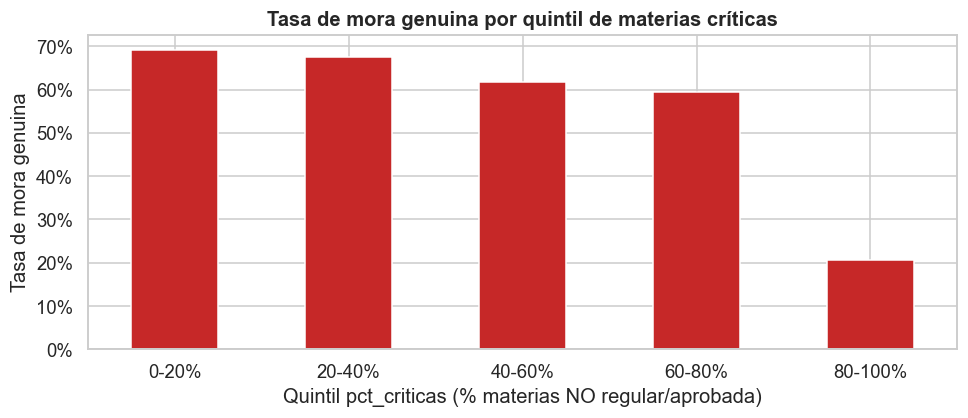

,AUC-ROC,F1,Precision,Recall
Variante,,,,
Sin académicas (27 features),0.9269,0.8474,0.8509,0.8440
Con rendimiento académico (32 features),0.9289,0.8489,0.8532,0.8447


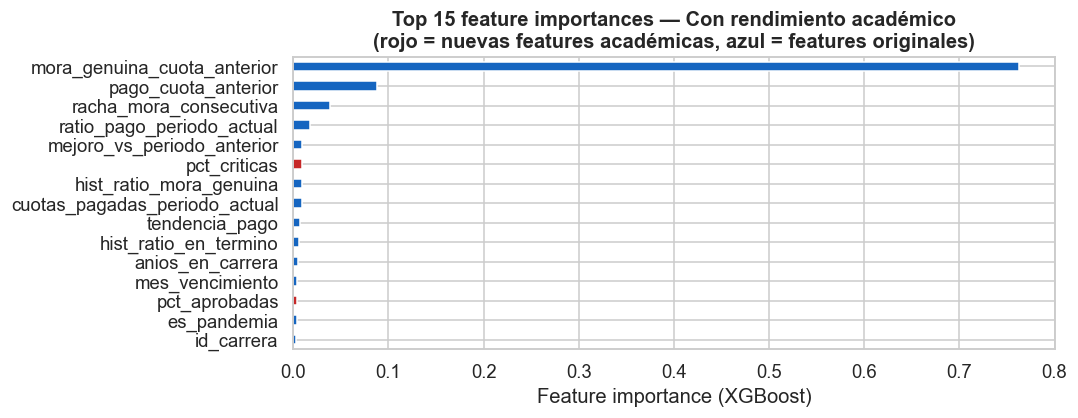


Ranking de features académicas en importancias:
  n_materias_total: #21 de 32
  pct_aprobadas: #13 de 32
  pct_regulares: #22 de 32
  pct_vencidas: #17 de 32
  pct_criticas: #6 de 32


In [22]:
# ── Join con el dataset de entrenamiento ──────────────────────────────────────
FEATS_ACAD = ['n_materias_total', 'pct_aprobadas', 'pct_regulares',
               'pct_vencidas', 'pct_criticas']

df_academico['id_alumno'] = pd.to_numeric(df_academico['id_alumno'], errors='coerce')

df_acad = df.copy()
df_acad = df_acad.merge(
    df_academico[['id_alumno'] + FEATS_ACAD],
    on='id_alumno', how='left'
)

cobertura = df_acad[FEATS_ACAD[0]].notna().mean()
print(f'Cobertura del join: {cobertura:.1%} de cuotas tienen info académica')

# Imputar con mediana (alumnos sin registro en alumno_asignatura)
for col in FEATS_ACAD:
    med = df_acad[col].median()
    df_acad[col] = df_acad[col].fillna(med)

# ── Análisis previo: mora vs pct_criticas ────────────────────────────────────
df_acad['criticas_bin'] = pd.qcut(df_acad['pct_criticas'], q=5,
                                    labels=['0-20%','20-40%','40-60%','60-80%','80-100%'],
                                    duplicates='drop')
mora_por_criticas = df_acad.groupby('criticas_bin', observed=True)[TARGET].mean()

fig, ax = plt.subplots(figsize=(9, 4))
mora_por_criticas.plot(kind='bar', ax=ax, color='#c62828', edgecolor='white')
ax.set_title('Tasa de mora genuina por quintil de materias críticas', fontweight='bold')
ax.set_xlabel('Quintil pct_criticas (% materias NO regular/aprobada)')
ax.set_ylabel('Tasa de mora genuina')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

# ── Entrenamiento temporal split con y sin features académicas ────────────────
feats_acad_full = feats_full + FEATS_ACAD

mask_tr_a = df_acad['periodo'].between(2020, 2023)
mask_te_a = df_acad['periodo'].between(2024, 2025)
y_tr_a = df_acad.loc[mask_tr_a, TARGET].astype(int)
y_te_a = df_acad.loc[mask_te_a, TARGET].astype(int)

def _prep_acad(feats):
    X = df_acad[feats].copy()
    X['id_carrera'] = LabelEncoder().fit_transform(X['id_carrera'].astype(str).str.strip())
    imp = SimpleImputer(strategy='median', keep_empty_features=True)
    return imp.fit_transform(X.loc[mask_tr_a]), imp.transform(X.loc[mask_te_a])

Xtr_base_a, Xte_base_a = _prep_acad(feats_full)
Xtr_acad,   Xte_acad   = _prep_acad(feats_acad_full)

m_base_a = _train_xgb(Xtr_base_a, y_tr_a)
m_acad   = _train_xgb(Xtr_acad,   y_tr_a)

prob_acad = m_acad.predict_proba(Xte_acad)[:, 1]
pred_acad = m_acad.predict(Xte_acad)

res_acad = pd.DataFrame([
    _metrics(m_base_a, Xte_base_a, y_te_a, f'Sin académicas ({len(feats_full)} features)'),
    {'Variante':    f'Con rendimiento académico ({len(feats_acad_full)} features)',
     'AUC-ROC':    round(roc_auc_score(y_te_a, prob_acad), 4),
     'F1':         round(f1_score(y_te_a, pred_acad), 4),
     'Precision':  round(precision_score(y_te_a, pred_acad), 4),
     'Recall':     round(recall_score(y_te_a, pred_acad), 4),
     'n_features': Xte_acad.shape[1]},
]).set_index('Variante')

display(
    res_acad[['AUC-ROC', 'F1', 'Precision', 'Recall']]
    .style
    .highlight_max(axis=0, props='background-color: #1b5e20; color: #fff; font-weight:600')
    .format('{:.4f}', subset=['AUC-ROC', 'F1', 'Precision', 'Recall'])
)

# ── Importancias de features académicas ──────────────────────────────────────
feat_names_acad = feats_acad_full.copy()
fi_acad = pd.Series(m_acad.feature_importances_, index=feat_names_acad)

fig, ax = plt.subplots(figsize=(10, 4))
fi_top = fi_acad.sort_values(ascending=True).tail(15)
colors = ['#c62828' if f in FEATS_ACAD else '#1565c0' for f in fi_top.index]
fi_top.plot(kind='barh', ax=ax, color=colors)
ax.set_title(
    'Top 15 feature importances — Con rendimiento académico\n'
    '(rojo = nuevas features académicas, azul = features originales)',
    fontweight='bold'
)
ax.set_xlabel('Feature importance (XGBoost)')
plt.tight_layout()
plt.show()

print('\nRanking de features académicas en importancias:')
for feat in FEATS_ACAD:
    rank = int(fi_acad.rank(ascending=False)[feat])
    print(f'  {feat}: #{rank} de {len(feat_names_acad)}')

---

# Resumen ejecutivo y conclusiones

> **Estado:** baseline ejecutado · experimentos 1-5 listos para correr (celdas 22-34)

---

## 1. Dataset

| Ítem | Valor |
|------|-------|
| Filas totales | 461 984 cuotas |
| Período cubierto | 2020 – 2025 |
| Target (`target_mora_genuina`) | 55.9 % mora · 44.1 % pago |
| Features usadas (baseline) | 27 |
| Features con rendimiento académico | 32 |

---

## 2. Resultados baseline — split aleatorio 80/20

Todos los modelos se entrenaron con el mismo set estratificado. Los árboles con boosting dominan claramente a la regresión logística.

| Modelo | AUC-ROC | F1 | Precision | Recall | Balanced Acc |
|--------|---------|----|-----------|--------|--------------|
| **XGBoost** ★ | **0.9462** | **0.8910** | 0.8815 | **0.9008** | **0.8736** |
| LightGBM | 0.9454 | 0.8903 | 0.8805 | 0.9003 | 0.8728 |
| Random Forest | 0.9448 | 0.8905 | 0.8804 | 0.9007 | 0.8729 |
| Logistic Regression | 0.8815 | 0.8620 | **0.8867** | 0.8386 | 0.8514 |

**XGBoost es el mejor modelo global** con AUC 0.9462 y recall 0.9008.  
LightGBM y Random Forest son prácticamente equivalentes (~0.001 de diferencia).

---

## 3. Robustez del split — validación metodológica

Se compararon tres protocolos con **Logistic Regression** (rápida e interpretable como referencia metodológica):

| Protocolo | AUC-ROC | F1 | Nota |
|-----------|---------|-----|------|
| Aleatorio por filas | 0.8815 | 0.8620 | ⚠ Optimismo: 99.98 % de alumnos del test ya están en train |
| Split por alumno | 0.8794 | 0.8583 | Corrije la fuga de identidad entre conjuntos |
| **Split temporal 2020-23 → 2024-25** | **0.8636** | **0.8230** | ✓ Simula predicción real del futuro |

**Conclusión crítica:** el split aleatorio infla el AUC ~0.02 pts porque el modelo aprende a *reconocer alumnos*, no a *predecir mora*. El split temporal es el único que mide capacidad predictiva genuina. La caída de AUC (0.88 → 0.86) y de F1 (0.86 → 0.82) indica que el contexto 2024-2025 (crisis económica, inflación post-shock) introduce distributional shift que el modelo tiene que aprender a absorber.

---

## 4. Experimentos implementados (pendientes de ejecución)

### Exp. 1 — ¿Modelo perezoso? (celdas 22-23)

Entrena XGBoost en split temporal con y sin `pago_cuota_anterior` / `mora_genuina_cuota_anterior`.  
**Hipótesis:** si el delta AUC es > 0.02, el modelo depende excesivamente del historial inmediato y no es útil para predicciones al inicio del cuatrimestre.

### Exp. 2 — Contexto macroeconómico (celdas 24-25)

Agrega `inflacion_anual_pct` (datos INDEC: 36 % en 2020 → 211 % en 2023 → 118 % en 2024).  
**Hipótesis:** la inflación explica parte del aumento de mora en 2024 con independencia del perfil del alumno.

### Exp. 3 — Error por carrera (celdas 26-27)

Calcula AUC y tasa de error por `id_carrera` sobre el test temporal.  
**Hipótesis:** carreras de salud o ingeniería tienen perfiles de pago distintos; si el AUC cae bajo 0.80 en alguna, merece un sub-modelo.

### Exp. 4 — Umbral de negocio (celdas 28-29)

Barre thresholds con `COST_FN = 5 × COST_FP` para minimizar el costo real.  
**Hipótesis:** el umbral óptimo está por debajo de 0.5, aumentando el recall a costa de más alertas administrativas. La universidad puede ajustar el ratio.

### Exp. 5 — Rendimiento académico (celdas 32-34)

Agrega `pct_criticas`, `pct_aprobadas`, `pct_vencidas`, `pct_regulares` y `n_materias_total` desde `alumno_asignatura` vía MySQL.  
**Hipótesis:** alumnos con alta proporción de materias vencidas o libres tienen mayor probabilidad de mora arancelaria — el rezago académico correlaciona con dificultades económicas.  
**Join completo:** `alumno_asignatura` → `asignatura` → `planes_oe` → `oferta_educativa` para contextualizar el avance real sobre el plan de carrera.

---

## 5. Factores externos a incorporar en próximas iteraciones

El IPC anual fue el primer indicador macro incluido. A continuación se listan otros factores externos medibles que pueden mejorar la robustez del modelo ante cambios de contexto:

| Factor | Variable sugerida | Fuente | Hipótesis |
|--------|------------------|--------|-----------|
| **Tipo de cambio** | Brecha % dólar oficial/blue al vencimiento | BCRA / Ambito | Incertidumbre cambiaria → mora preventiva |
| **Desempleo** | Tasa desocupación trimestral (Gran Tucumán) | INDEC EPH | Desempleo regional impacta directamente |
| **Salario real** | SMVM deflactado por IPC | MTEySS | Pérdida de poder adquisitivo → dificultad de pago |
| **Ciclo electoral** | Año electoral binario (2021, 2023, 2025) | Calendario | Volatilidad económica pre/post elecciones |
| **Días hábiles del mes** | Cantidad de días hábiles entre emisión y vencimiento | Calendarios | Meses con feriados concentrados → atrasos |
| **Temperatura / receso** | Meses de julio y enero (receso invernal/verano) | Calendario académico | Alumnos ausentes → menor seguimiento de deuda |
| **Tasa activa bancaria** | Tasa nominal anual de préstamos personales | BCRA | Endeudamiento bancario compite con cuotas universitarias |

---

## 6. Próximos pasos recomendados

1. **Correr celdas 22-29** y observar los deltas de los 4 experimentos.
2. Incorporar al menos **tipo de cambio + SMVM deflactado** como features macro adicionales (alta disponibilidad, granularidad mensual).
3. Si Exp. 3 revela carreras con AUC < 0.80, entrenar un **XGBoost especializado por facultad**.
4. Definir con las autoridades el ratio `COST_FN / COST_FP` para fijar el umbral de producción.
5. Evaluar si reemplazar `pago_cuota_anterior` por `hist_ratio_pago` (promedio histórico anual) mejora la utilidad para predicciones de largo plazo.
6. Si Exp. 5 muestra que `pct_criticas` rankea alto en importancias, investigar si existe un **snapshot histórico de `alumno_asignatura`** para evitar data leakage temporal y construir features de trayectoria académica año a año.
